# SMS Spam & Phishing Detection

This notebook covers the full pipeline:
- Data loading and exploration
- Text preprocessing
- Feature extraction (TF-IDF)
- Model training and evaluation
- Saving the best model for deployment

The saved model is served via a **FastAPI** backend and a **Streamlit** frontend.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

Using the UCI SMS Spam Collection dataset.  
Columns: `label` (ham / spam) and `message`.

In [2]:
df = pd.read_csv('spam.csv',encoding='latin-1', usecols=[0, 1])
df.columns = ['label', 'message']

print('Shape:', df.shape)
df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Exploratory Data Analysis

In [3]:
print('Label distribution:')
print(df['label'].value_counts())
print()
print('Missing values:', df.isnull().sum().sum())

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values: 0


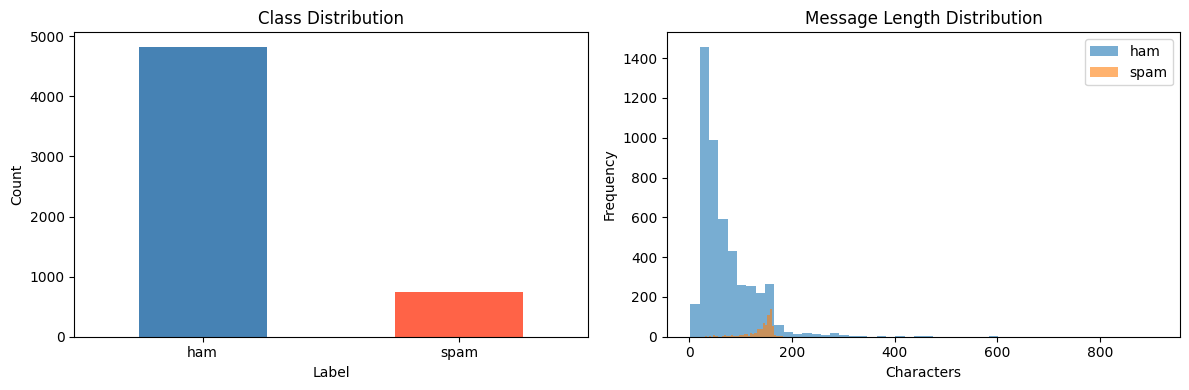

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Message length distribution
df['msg_length'] = df['message'].apply(len)
df.groupby('label')['msg_length'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[1])
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend(['ham', 'spam'])

plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [5]:
def clean_text(text):
    """Lowercase, remove punctuation and extra whitespace."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)               # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)

# Encode label: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print('Sample after cleaning:')
df[['message', 'clean_message', 'label_num']].head()

Sample after cleaning:


,message,clean_message,label_num
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,0


## 5. Train / Test Split

In [6]:
X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')

Train size : 4457
Test size  : 1115


## 6. Model Training

Each model is wrapped in a `Pipeline` with a TF-IDF vectoriser so the
full pipeline (vectoriser + classifier) can be pickled and served directly.

In [9]:
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)),
        ('clf',   MultinomialNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Linear SVC': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)),
        ('clf',   LinearSVC(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)),
        ('clf',   RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    results[name] = {'pipeline': pipeline, 'preds': preds, 'accuracy': acc}
    print(f'{name:22s} -> Accuracy: {acc:.4f}')

Naive Bayes            -> Accuracy: 0.9596
Logistic Regression    -> Accuracy: 0.9686
Linear SVC             -> Accuracy: 0.9865
Random Forest          -> Accuracy: 0.9704


## 7. Evaluation

In [12]:
for name, info in results.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, info['preds'], target_names=['ham', 'spam']))


--- Naive Bayes ---
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115


--- Logistic Regression ---
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


--- Linear SVC ---
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weig

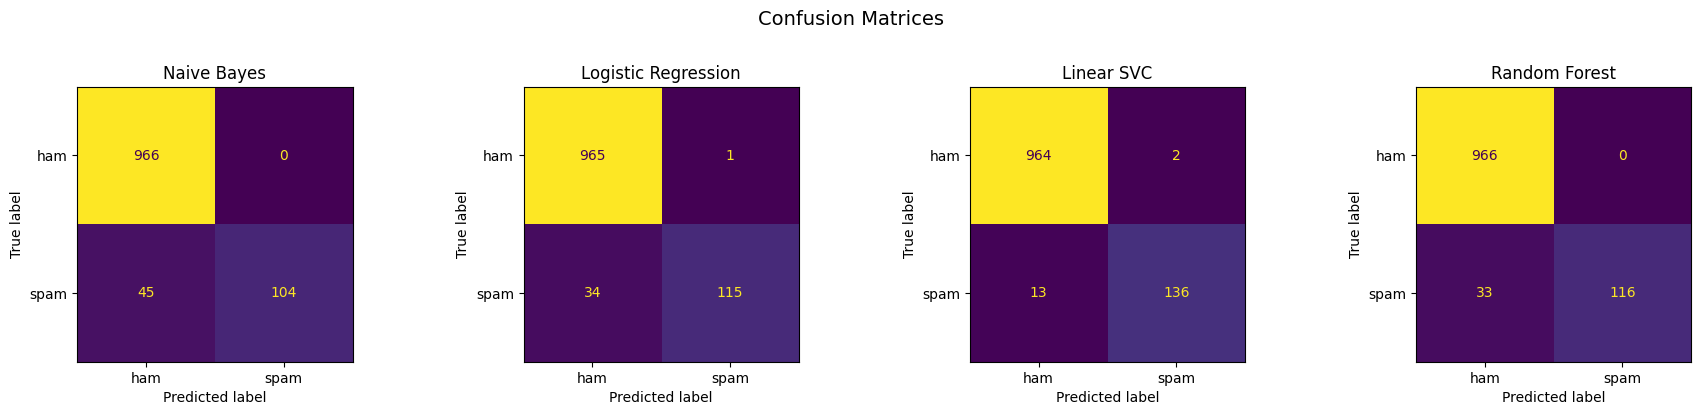

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, info) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, info['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

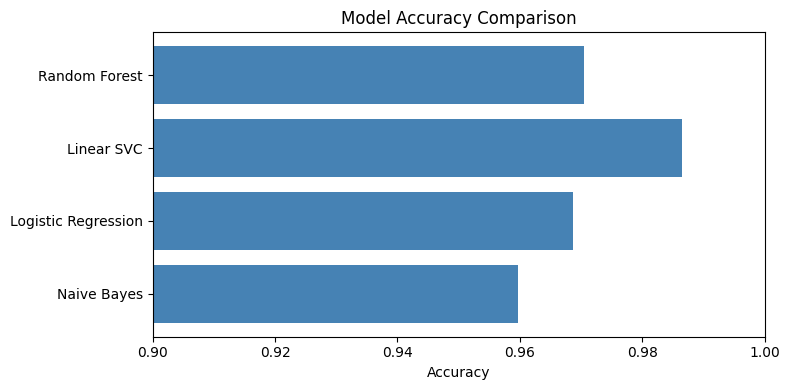

In [14]:
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]

plt.figure(figsize=(8, 4))
bars = plt.barh(names, accs, color='steelblue')
plt.xlim(0.9, 1.0)
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.tight_layout()
plt.show()

## 8. Select & Save Best Model

In [15]:
best_name = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['pipeline']

print(f'Best model : {best_name}')
print(f'Accuracy   : {results[best_name]["accuracy"]:.4f}')

with open('Backend/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Model saved to Backend/best_model.pkl')

Best model : Linear SVC
Accuracy   : 0.9865
Model saved to Backend/best_model.pkl


## 9. Quick Sanity Check

In [16]:
test_messages = [
    "Congratulations! You won a free iPhone. Click here to claim now!",
    "Hey, are we still on for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now at http://fake-bank.com",
    "Please find the meeting notes attached.",
]

with open('Backend/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print(f"{'Message':<55} Prediction")
print('-' * 70)
for msg in test_messages:
    pred = loaded_model.predict([clean_text(msg)])[0]
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"{msg[:54]:<55} {label}")

Message                                                 Prediction
----------------------------------------------------------------------
Congratulations! You won a free iPhone. Click here to   SPAM
Hey, are we still on for lunch tomorrow?                HAM
URGENT: Your account has been compromised. Verify now   SPAM
Please find the meeting notes attached.                 HAM


## 12. Project Summary

| Step | Detail |
|------|--------|
| Dataset | UCI SMS Spam Collection (5 572 messages) |
| Preprocessing | Lowercase, remove URLs / digits / punctuation |
| Features | TF-IDF unigrams + bigrams (top 10 000) |
| Models | Naive Bayes, Logistic Regression, Linear SVC, Random Forest |
| Best model | Saved as `Backend/best_mode.pkl` |